# One scorecard for every measurement: 3D true vs 3D stitched

Cellpose can segment a stack two ways — natively in 3D (`do_3D`), or per z-plane
with the 2D masks stitched afterwards (`stitch_threshold`). Three measurements
decide between them, each lifted from one of this repo's scripts:

| script | question | what a bad answer looks like |
|---|---|---|
| `segmentation_z_claude.py` | how far does each mask reach through z? | a pile of masks on one or two planes (yield a `min_z` filter discards), or a tail reaching through the whole stack (two nuclei read as one) |
| `segmentation_z_area_sway_claude.py` | does the area-through-z profile wander, or jump? | a profile that turns around plane after plane, or a corner: a flat run, a jump, another flat run |
| `segmentation_z_brightness_claude.py` | do the claimed voxels look like signal? | a masked brightness distribution sliding left toward the unmasked one |

Each of them answers for **one run**. This notebook runs all three on the same
volumes and reduces them to **one row per (region, FOV, technique)** — the
individual statistics, then three group scores, then a weighted total out of
1.00. The weighting is a rubric — `0.20` span, `0.30` jitter, `0.20` sway,
`0.30` brightness — and section 6 says why those numbers.

`segmentation_helpers_v2.py` is the aggregator. It re-implements no measurement:
`check_area_jitter`, `check_area_sway`, `vectorise_pixels` /
`accumulate_histograms` and the histogram
statistics are imported from the scripts and called.

### Two scripts are deliberately left out

`segmentation_z_kanai_only.py` does `import napari` at module scope, which a
headless kernel cannot do, and its z-span maths is the first row of the table.

**Per-transition area change is not measured at all** — the second half of
`segmentation_z_claude.py`, and the whole of
`segmentation_z_claude_log_cutoff.py`. Sway subsumes it and is the sharper
instrument. |Δ area| / area asks *how much did this cross-section change between
two planes*, which is large for a perfectly healthy nucleus growing steeply
toward its mid-plane. The failure actually being chased is a **corner** — a flat
run, a jump, another flat run — and on the change metric a steep smooth grower
outscores a real stitching step. Sway is a *second* difference: blind to growth
rate, sensitive only to growth rate changing, which is exactly what separates a
segmenter gluing two objects together from a nucleus getting bigger. Keeping both
would have put a noisier restatement of a worse question on the card and let it
cost a technique points.

Sections 1–4 walk a single field so each measurement can be seen on its own;
sections 5–6 scan every region and score each one on its own card; section 7 puts
every flagged mask on one napari viewer.

## Two decisions apply to everything below

### Single-slice masks are removed before anything is measured

A mask living on exactly one z plane is an imaging artifact, not a nucleus. It
is dropped from the volume **first**, so it stops counting as a mask *and* its
voxels go back into the unmasked brightness pool — the filter has to happen
upstream of every metric or the brightness figures would still be scoring it.

Per-plane stitching is what produces them, so the obvious thing is to filter only
the stitched arm. `DROP_SINGLE_SLICE_IN` in the config does exactly that if you
want it, but the default applies the filter to **both**: removing masks from one
arm and not the other moves every rate in that arm's favour, because the masks
that survive are the thicker ones. Its thin rate, its median z-span and its
jitter rate improve for free, and none of that improvement is a segmenter doing
better. Whatever the setting, the counts removed are printed and carried in the
metrics table as `n_dropped` / `pct_dropped` — reported, never scored, because an
artifact of the imaging is not a defect of the segmenter.

### Nothing here assumes a normal distribution

Every distribution in this notebook is skewed and most are visibly so: a jitter
is a spike at 1.0x with a sparse tail running past 100, z-span is a small integer
count, voxel brightness is bimodal by construction. So:

* **centre and spread** are the median and the IQR. The scripts' means are still
  computed and still printed — they simply do not drive anything.
* **the profile cutoffs** are absolute (`JITTER_CUTOFF`, `SWAY_CUTOFF`) rather
  than the script's default 90th percentile. Both are ratios of ratios and so
  dimensionless, and a fixed number then means the same thing in every FOV —
  where a quantile cutoff flags the top 10% of every FOV *by construction*,
  which is a useful shortlist to look at and a useless number to compare
  techniques on, since both would score 10.0% every time. **Both shipped values
  are provisional**; section 3 is where you set them from the data.
* **separability** is the rank-based AUC, under a name that says what it
  measures: P(a random masked voxel outshines a random unmasked one). The
  brightness table adds two rank rates the script did not have.

Comparing the two techniques is left to the eye and the per-region cards. The
paired machinery — Wilcoxon signed-rank, Hodges–Lehmann shift, matched-pairs
rank-biserial, percentile bootstrap — is still in `segmentation_helpers_v2.py`
(`compare_techniques`, `plot_paired`, `technique_summary`) if you want it back.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import segmentation_helpers_v2 as v2
import segmentation_brightness_helpers as bh   # the two-panel brightness figure

v2.apply_theme()          # same figure style as the other two notebooks
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 80)

### Config

`TECHNIQUE_ROOTS` points at the directory *above* the region under each technique
tree; `DAPI_PATCHES` is the matching patches directory, and the region name is
appended to both wherever it is needed. Every cutoff the notebook uses is here,
and every one of them is absolute — none is a quantile of the FOV it is applied
to, so a number means the same thing in every field.

In [2]:
DATA_ROOT = Path("../data")

FAMILY = "cpdino"
PREPROCESSING = "decon"
MODEL = "VePo"

TECHNIQUE_ROOTS = {
    "3D true":     DATA_ROOT / "segmentations_3d_true"     / FAMILY / PREPROCESSING / MODEL,
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL,
}
DAPI_PATCHES = DATA_ROOT / "patches" / MODEL

# the single field sections 1-4 walk through
REGION = "region_UWA-7648"
FOV    = "fov_07"

SCAN_REGIONS = None          # None -> every region present under both techniques
LAUNCH_NAPARI = False        # section 7 blocks the kernel until its windows close

# --- the single-slice filter -------------------------------------------------
DROP_SINGLE_SLICE = True
DROP_SINGLE_SLICE_IN = None  # None -> both techniques; ("3D stitched",) -> that one only

# --- z-span ------------------------------------------------------------------
THIN_MAX = 2                 # z_span <= this is what a min_z = 3 filter discards
DEEP_MIN = 6                 # z_span >= this is a mask reaching through the stack

# --- area profile: jitter (wobble) and sway (jump) ---------------------------
# Both are dimensionless, so an absolute cutoff means the same thing in every FOV.
# BOTH VALUES ARE PROVISIONAL -- they come from worked profiles, not from this
# data.  Section 3 draws the distributions; set them from the knee you see there.
JITTER_CUTOFF = 1.75         # total up-and-down travel; ordinary masks sit at 1.1-1.3.
                             # With one reversal this means the shallower limb of the V
                             # is over a 1.75x area change -- plateau noise (~1.5x) stays
                             # clear, a sharply peaked healthy nucleus (~2.5x) does not,
                             # which is the cost of counting the peak reversal at all
SWAY_CUTOFF = 3.0            # worst corner; a healthy arc ~2, a stitching step 10+
AREA_FLOOR = 20              # px; ratios between handfuls of pixels are noise
SLIVER_FRAC = 0.05           # a plane under this share of the mask's own peak area is
                             # a partial-volume sliver, and is left out of the profile

# everything analyse_fov / scan_regions needs, in one place
ANALYSIS = dict(jitter_cutoff=JITTER_CUTOFF, sway_cutoff=SWAY_CUTOFF,
                area_floor=AREA_FLOOR, sliver_frac=SLIVER_FRAC,
                thin_max=THIN_MAX, deep_min=DEEP_MIN)
FILTER = dict(drop=DROP_SINGLE_SLICE, drop_in=DROP_SINGLE_SLICE_IN)

for name, root in TECHNIQUE_ROOTS.items():
    print(f"{'OK ' if root.exists() else 'MISSING'}  {name:<12} {root}")
print(f"{'OK ' if DAPI_PATCHES.exists() else 'MISSING'}  {'DAPI':<12} {DAPI_PATCHES}")
print("\nregions under both techniques:", ", ".join(v2.available_regions(TECHNIQUE_ROOTS)))

OK   3D true      ../data/segmentations_3d_true/cpdino/decon/VePo
OK   3D stitched  ../data/segmentations_3d_stitched/cpdino/decon/VePo
OK   DAPI         ../data/patches/VePo

regions under both techniques: region_UCI-2424, region_UCI-4723, region_UCI-5224, region_UWA-7648


## 1. The single-slice filter

Both techniques segmented the same DAPI stack, so it is read once and reused —
`h.load_data` would re-read it per technique, and it is also what the brightness
bins are built from, which both techniques then have to share.

First, the volumes as they came off disk.

In [3]:
found = v2.find_region_fovs(TECHNIQUE_ROOTS, REGION)
paths = found[found["fov"] == FOV].set_index("method")["path"]

dapi, files = v2.load_dapi(v2.fov_dapi_glob(DAPI_PATCHES / REGION, FOV))
edges, exact = v2.b.build_bin_edges(dapi)
print(f"{len(files)} DAPI planes, shape {dapi.shape}, dtype {dapi.dtype}\n")

raw = {}
for method, path in paths.items():
    masks = v2.load_masks(path)
    spans = v2.span_table(v2.measure_slice_areas(masks))
    raw[str(method)] = {"masks": masks, "spans": spans}
    n_single = int((spans["z_span"] == 1).sum())
    print(f"{str(method):<12} {len(spans):>5} masks   "
          f"{n_single:>5} of them single-slice ({100 * n_single / len(spans):5.1f}%)")

7 DAPI planes, shape (7, 4000, 4000), dtype uint16

3D true       1871 masks       0 of them single-slice (  0.0%)
3D stitched   2931 masks     377 of them single-slice ( 12.9%)


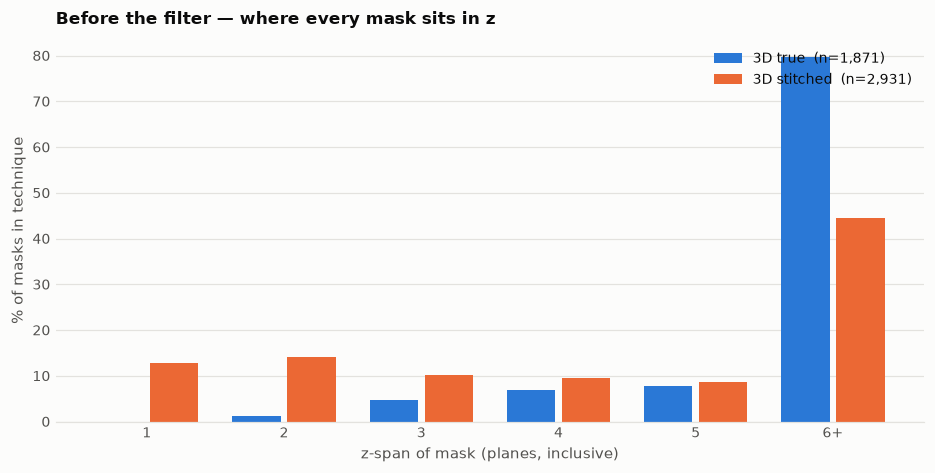

In [4]:
raw_labels = pd.concat([v2.tag(entry["spans"], method) for method, entry in raw.items()],
                       ignore_index=True)
fig = v2.compare_span_distribution(
    raw_labels, max_span=DEEP_MIN,
    title="Before the filter — where every mask sits in z")

The bar at 1 is the artifacts. Everything downstream — the thin rate, the median
z-span, the jitter distribution, the share of voxels a technique claims — is
computed on a population that is mostly them, in whichever arm produces them.

`analyse_fov` drops them first and then runs all four measurements on what is
left. The same call is what section 6 uses on every FOV, so the numbers in the
walk-through are the numbers in the scorecard.

In [5]:
runs = {}
for method, entry in raw.items():
    runs[method] = v2.analyse_fov(
        entry["masks"], dapi=dapi, edges=edges, exact=exact,
        drop=v2.drops_here(method, DROP_SINGLE_SLICE_IN, DROP_SINGLE_SLICE),
        **ANALYSIS)
    report = runs[method]["report"]
    print(f"{method:<12} {report['n_total']:>5} masks in  ->  "
          f"{report['n_total'] - report['n_dropped']:>5} kept   "
          f"({report['n_dropped']} single-slice dropped, "
          f"{report['pct_dropped']:.1f}%)")

labels = pd.concat([v2.tag(run["labels"], method) for method, run in runs.items()],
                   ignore_index=True)

3D true       1871 masks in  ->   1871 kept   (0 single-slice dropped, 0.0%)
3D stitched   2931 masks in  ->   2554 kept   (377 single-slice dropped, 12.9%)


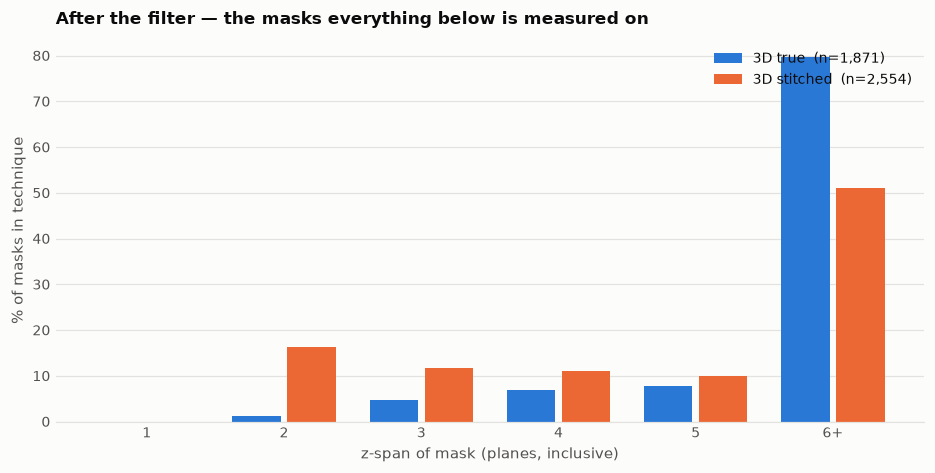

In [6]:
fig = v2.compare_span_distribution(
    labels, max_span=DEEP_MIN,
    title="After the filter — the masks everything below is measured on")

## 2. Where the surviving masks sit in z

Two columns come out of the span table that the z bounding box alone does not
give you. `n_planes` is how many planes a label actually occupies, against
`z_span`, which is the inclusive depth of its bounding box. They differ only when
the label has a hole in z — and **a mask that vanishes for a plane and comes back
is two objects stitched into one**, a harder error than plain over-merging and
one `find_objects` will not show you.

`% thin` is what a `min_z = 3` filter throws away; `% deep` is masks reaching most
of the way through the stack.

This table is where `% deep` and `% z-gap` are read from now on. Section 6 scores
`Span` on the thin rate alone, so these two are diagnostics rather than charges —
still measured on every FOV, still in `fov_metrics`, and still compared between
techniques in section 7.

In [7]:
per_method = labels.groupby("method", sort=False, observed=True)
pd.DataFrame({
    "n_masks": per_method.size(),
    "median_z_span": per_method["z_span"].median(),
    "IQR_z_span": (per_method["z_span"].quantile(0.75)
                   - per_method["z_span"].quantile(0.25)),
    "max_z_span": per_method["z_span"].max(),
    f"pct_thin (<={THIN_MAX})": 100 * per_method["thin"].mean(),
    f"pct_deep (>={DEEP_MIN})": 100 * per_method["deep"].mean(),
    "pct_z_gap": 100 * per_method["has_z_gap"].mean(),
}).round(2)

,n_masks,median_z_span,IQR_z_span,max_z_span,pct_thin (<=2),pct_deep (>=6),pct_z_gap
method,,,,,,,
3D true,1871,7.0,1.0,7,1.28,79.58,0.0
3D stitched,2554,6.0,4.0,7,16.29,51.06,0.0


In [8]:
# the masks with a hole in them, worst first
gapped = labels[labels["has_z_gap"]].copy()
gapped["missing_planes"] = gapped["z_span"] - gapped["n_planes"]
(gapped.sort_values(["missing_planes", "n_voxels"], ascending=False)
       .loc[:, ["method", "label", "z_start", "z_end", "z_span", "n_planes",
                "missing_planes", "area_median", "n_voxels"]]
       .head(10))

,method,label,z_start,z_end,z_span,n_planes,missing_planes,area_median,n_voxels


## 3. Jitter: does the profile wander up and down?

This is the larger half of the profile score, and the section that changed most.

### What the old metric actually flagged

Until this rework a single number stood for "is the profile smooth":

    sway = 10 ** max | log10(a[z+1]) − 2 log10(a[z]) + log10(a[z−1]) |

the largest second difference of log area over three consecutive planes. Drawn
over real data, every one of its worst offenders turned out to be a **ramp**: a
near-vertical rise from ~16 px to ~2,000 px at the mask's second plane, with the
flagged plane sitting at the top of that rise every single time. None of them
wandered. Three separate things were wrong:

* **`max` is an extreme-value statistic.** One transition decides the score, so
  the metric structurally cannot rank sustained wobble above a single jump. Ten
  alternating 1.5x wobbles score 2.25x; one clean monotone 100x step scores 58x.
* **A magnitude of curvature is blind to direction.** `|Δ² log a|` asks how much
  the growth *rate* changed, never whether the profile *turned around*. A
  monotone accelerating rise and a genuine up-down-up of the same size score
  identically.
* **The partial-volume sliver was measured.** `AREA_FLOOR` *clamped* the areas
  (`np.maximum`) instead of excluding them, so a 16 px onset plane became 20 px
  and still acted as the left leg of the first triple. Every nucleus enters and
  leaves the stack through a sliver, so **every** mask carried a ~100x step by
  construction — worth 58x against a 3.0x cutoff.

Between them, the flag was close to a ranking of onset steepness, which tracks
where a nucleus sits in the stack rather than how well it was segmented.

### `jitter`, the replacement

    d[k]     = log10(a[k+1]) − log10(a[k])        per-step log growth
    reversal = sign(d[k]) ≠ sign(d[k+1])          the profile turned around
    w[k]     = min(|d[k]|, |d[k+1]|)              how deep the V goes
    jitter   = 10 ** Σ w[k] over reversals        a factor, ≥ 1.0

Two choices carry it. Weighting a reversal by the **smaller** of its two limbs is
what makes a ramp free: a huge rise followed by a small dip is worth the small
dip, so an onset ramp cannot dominate even if a sliver survives the filter. And
**summing** rather than maxing is what lets many small wobbles outscore one big
excursion — the property `max` structurally denies.

| profile | jitter | sway |
|---|---|---|
| monotone ramp, any steepness | **1.00** | ~1.5 |
| flat, one 10x jump, flat | **1.00** | **10.0** |
| grow → peak → shrink | 1.16 | 2.3 |
| ±10% noise on a plateau | 1.48 | 1.2 |
| up-down-up-down | **53** | 7.5 |

A healthy nucleus is unimodal — it grows to its mid-plane and shrinks — so it
contains exactly one reversal at the peak and lands a little above 1.0. That peak
is **not** exempt, which is why the cutoff has to sit above the ordinary bulk
rather than at 1.0.

### `sway`, the old maths, kept

Look at the second row of that table: the flat-run/jump/flat-run of an over-merge
is *monotone*. It never reverses, so `jitter` scores it a clean 1.00 and would
let it through. That defect is real and worth catching, so the old second
difference keeps its name and stays as its own line — repaired by the sliver
exclusion, so that it now measures a corner in the middle of a profile rather
than every mask's onset. What changed about `sway` is not the maths; it is that
it no longer has to stand for wobble as well.

### Both cutoffs are provisional

`JITTER_CUTOFF = 1.75` and `SWAY_CUTOFF = 3.0` come from the worked profiles in
that table, not from this data. The two figures below are how you set them: look
for the knee where the ordinary bulk ends and the tail begins, put a round number
just above it, and check the worst offenders look like what you meant to catch.

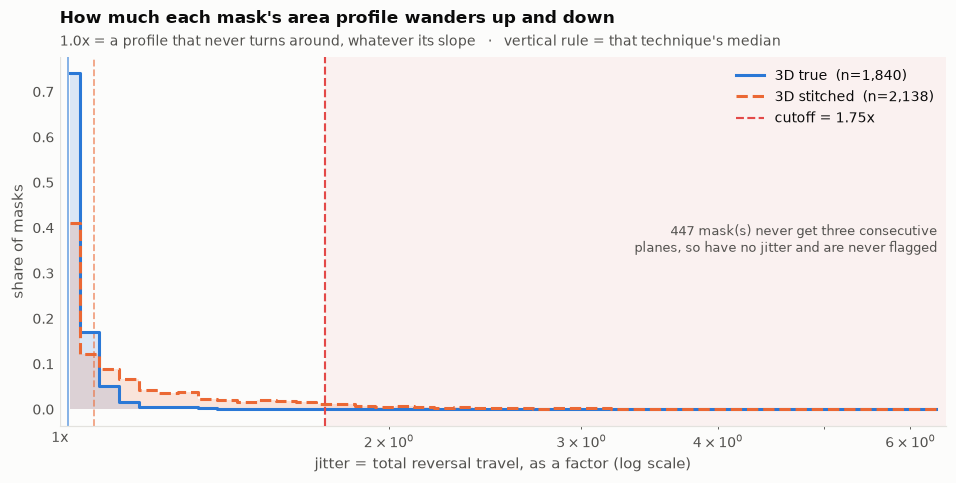

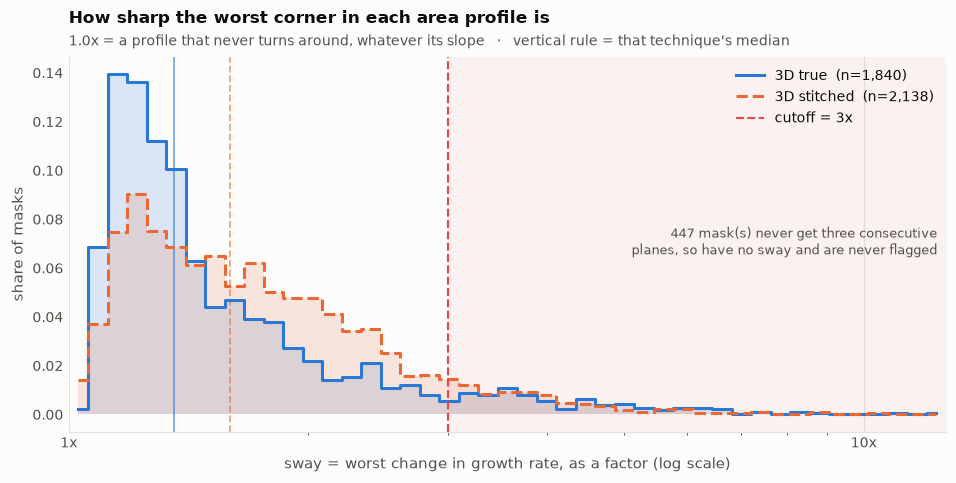

In [9]:
fig = v2.compare_profile_distribution(labels, "jitter", cutoff=JITTER_CUTOFF)
fig = v2.compare_profile_distribution(labels, "sway", cutoff=SWAY_CUTOFF)

In [10]:
per_method = labels.groupby("method", sort=False, observed=True)
for column, cutoff in (("jitter", JITTER_CUTOFF), ("sway", SWAY_CUTOFF)):
    display(pd.DataFrame({
        f"n_with_{column}": per_method[column].count(),
        "median": per_method[column].median(),
        "p75": per_method[column].quantile(0.75),
        "p90": per_method[column].quantile(0.90),
        "p99": per_method[column].quantile(0.99),
        "max": per_method[column].max(),
        # over the masks that have the metric, as the scorecard scores it
        f"pct > {cutoff:g}x": (100 * per_method[f"large_{column}"].sum()
                               / per_method[column].count()),
    }).round(2))

# the worst wanderers: z_at_jitter is the middle plane of the deepest reversal,
# i.e. the plane to scroll to in section 7's viewer.  n_reversals says how many
# times the profile turned around; n_planes_used says how many planes survived
# the sliver filter.
(labels.sort_values("jitter", ascending=False)
       .loc[:, ["method", "label", "z_start", "z_end", "n_planes", "n_planes_used",
                "area_min", "area_max", "n_reversals", "jitter", "z_at_jitter",
                "sway"]]
       .head(10))

,n_with_jitter,median,p75,p90,p99,max,pct > 1.75x
method,,,,,,,
3D true,1840,1.02,1.04,1.08,1.29,1.83,0.05
3D stitched,2138,1.07,1.26,1.64,3.20,6.47,7.62


,n_with_sway,median,p75,p90,p99,max,pct > 3x
method,,,,,,,
3D true,1840,1.36,1.76,2.61,5.86,12.69,7.66
3D stitched,2138,1.59,2.10,2.77,5.05,10.53,7.86


,method,label,z_start,z_end,n_planes,n_planes_used,area_min,area_max,n_reversals,jitter,z_at_jitter,sway
2917,3D stitched,1119,0,6,7,7,3592,7564,4,6.469213,3,3.630681
2336,3D stitched,503,0,6,7,7,1168,3984,4,6.251092,2,8.644211
2404,3D stitched,577,0,6,7,7,3104,7232,4,5.494279,5,4.395579
3434,3D stitched,1675,0,6,7,7,2288,6112,5,5.161625,3,3.131362
2249,3D stitched,405,0,6,7,7,4112,9344,3,5.050939,2,4.801163
3065,3D stitched,1279,0,6,7,7,4400,14384,3,4.776316,4,6.707229
3500,3D stitched,1748,1,6,6,6,2432,7920,2,4.690000,3,7.327149
3322,3D stitched,1552,0,6,7,7,3424,8960,4,4.640171,3,5.885223
3321,3D stitched,1551,0,3,4,4,512,3296,2,4.494400,1,10.533750
3806,3D stitched,2084,2,6,5,5,960,6144,2,4.405340,4,8.662500


## 4. Brightness: do the claimed voxels look like signal?

Every voxel contributes one `(brightness, is_masked)` pair. A technique picking
up nuclei puts bright voxels inside its masks and leaves dim ones outside; one
that over-grows its masks drags background in and its masked distribution slides
left toward the unmasked one.

Both techniques segment the same DAPI stack, so the bins were built once from
that stack in section 1 and both mask volumes were histogrammed onto them — two
distributions binned differently cannot be laid over each other. And because the
single-slice filter ran first, the artifacts' voxels are counted as *unmasked*
here, which is the whole reason the filter has to happen upstream.

Three of the columns are rank-based and need no assumption about shape:

* `separability` — P(a random masked voxel is brighter than a random unmasked
  one); this is the brightness script's `auc` under a name that says what it
  measures. 0.5 says brightness carries no information about what the technique
  masked. It is the only brightness column the scorecard scores, and it *is*
  the `Signal` score — section 6 uses it directly rather than rescaling it.
* `dim_masked_rate` — the share of masked voxels below the **unmasked** median.
  Masks placed at random score 0.5; background pulled into a mask pushes it up.
* `bright_unmasked_rate` — the share of unmasked voxels above the **masked**
  median: signal left behind. It is bounded below by how little of the volume is
  nucleus, so read it against `frac_masked`.

`median_shift_iqr` is the robust counterpart of a Cohen's *d*: the gap between
the two medians in units of the unmasked IQR.

`mean_masked` and `mean_unmasked` are the brightness script's own means, kept in
the units of the image. They are the one place a mean is quoted in this
notebook and nothing is scored on them — brightness is bimodal by construction,
so a mean over masked voxels sits between the two modes and describes neither.
What `mean_masked` does give you, which no rate can, is the plainest reading of
a mask there is: how bright is a voxel this technique claimed, against
`mean_unmasked` as the floor it should be well clear of.

In [11]:
brightness = pd.DataFrame({method: run["brightness"] for method, run in runs.items()}).T
brightness.round(4)

,n_voxels,n_masked,frac_masked,separability,mean_masked,mean_unmasked,median_masked,median_unmasked,median_shift_iqr,dim_masked_rate,bright_unmasked_rate,point_biserial_r
3D true,112000000.0,37662103.0,0.3363,0.9588,14451.2652,3001.3753,14670.3712,2000.8057,4.6267,0.0171,0.0066,0.8046
3D stitched,112000000.0,50180273.0,0.4480,0.8821,11861.1338,2785.2927,12303.4002,1838.0928,4.4473,0.0906,0.0112,0.6714


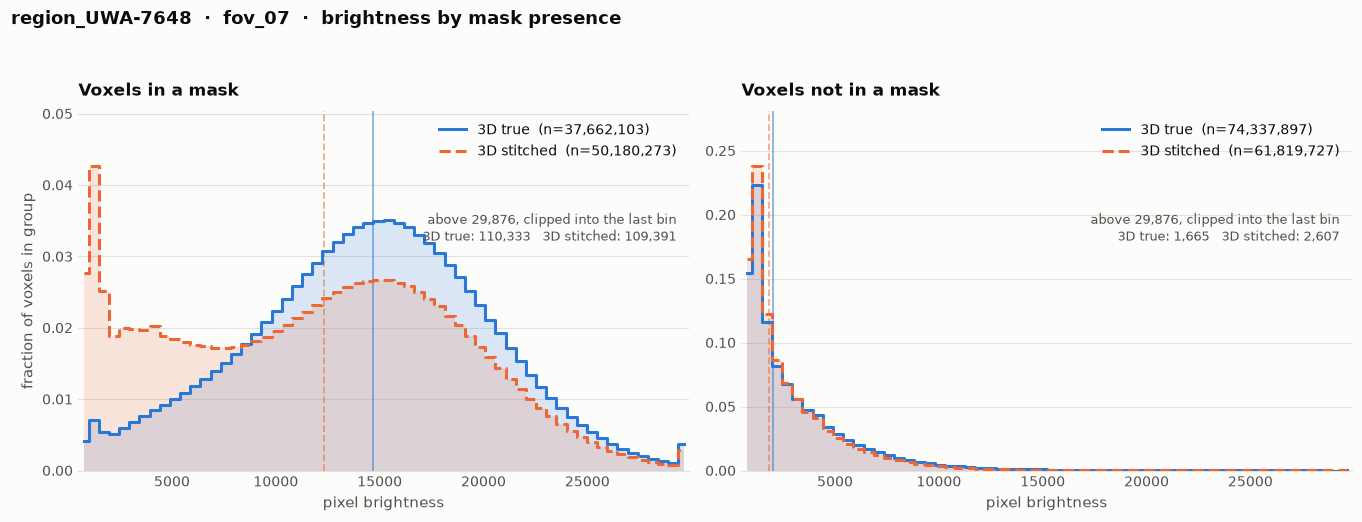

In [12]:
fig = bh.compare_brightness_distributions(
    {method: run["counts"] for method, run in runs.items()}, edges,
    title=f"{REGION}  ·  {FOV}  ·  brightness by mask presence",
    share_y=False)

## 5. Every FOV, every region

`find_region_fovs` drops any FOV only one technique produced and says which — a
ragged comparison is worse than a missing one — and pins technique order to
`TECHNIQUE_ROOTS` rather than the alphabet, so rows pair up the same way
everywhere.

`scan_regions` then runs section 1–5's `analyse_fov` on each pair. One DAPI stack
and one mask volume are resident at a time, so peak memory is set by the largest
FOV rather than by how many there are; only the tables and the histograms survive
the loop.

In [13]:
scan = v2.scan_regions(TECHNIQUE_ROOTS, DAPI_PATCHES, regions=SCAN_REGIONS,
                       **ANALYSIS, **FILTER)

print(f"\n{len(scan['labels']):,} masks "
      f"({int(scan['labels']['jitter'].notna().sum()):,} long enough to measure) "
      f"across {scan['filters'].index.get_level_values('fov').nunique()} FOV(s) "
      f"in {scan['filters'].index.get_level_values('region').nunique()} region(s)")


### region_UCI-2424
  fov_01     3D true        191 masks    185 measurable  (   0 single-slice dropped of   191)
  fov_01     3D stitched    218 masks    205 measurable  (  14 single-slice dropped of   232)
  fov_07     3D true       1452 masks   1405 measurable  (   0 single-slice dropped of  1452)
  fov_07     3D stitched   1957 masks   1640 measurable  ( 242 single-slice dropped of  2199)
  fov_09     3D true       1271 masks   1222 measurable  (   0 single-slice dropped of  1271)
  fov_09     3D stitched   1909 masks   1568 measurable  ( 365 single-slice dropped of  2274)

### region_UCI-4723
  fov_01     3D true         63 masks     59 measurable  (   0 single-slice dropped of    63)
  fov_01     3D stitched     76 masks     68 measurable  (   6 single-slice dropped of    82)
  fov_04     3D true        656 masks    639 measurable  (   0 single-slice dropped of   656)
  fov_04     3D stitched    901 masks    780 measurable  (  70 single-slice dropped of   971)
  fov_07     3D tr

### What the filter removed, run-wide

Reported, never scored. If one technique's `pct_dropped` is near zero and the
other's is large, that is the asymmetry the config note in the header is about —
and the reason the default filters both arms rather than one.

In [14]:
dropped = (scan["filters"]
           .groupby(level="method", sort=False, observed=True)
           .agg(n_fovs=("n_total", "size"), masks_in=("n_total", "sum"),
                single_slice=("n_dropped", "sum"),
                median_pct=("pct_dropped", "median"),
                min_pct=("pct_dropped", "min"), max_pct=("pct_dropped", "max")))
dropped["pct_of_all"] = 100 * dropped["single_slice"] / dropped["masks_in"]
dropped.round(2)

,n_fovs,masks_in,single_slice,median_pct,min_pct,max_pct,pct_of_all
method,,,,,,,
3D true,12,12229,2,0.00,0.00,0.09,0.02
3D stitched,12,18699,2125,9.32,6.03,16.05,11.36


In [15]:
metrics = v2.fov_metrics(scan["labels"], scan["brightness"], scan["filters"])
metrics.round(3)

n_masks  pct_thin  pct_deep  pct_z_gap  median_z_span  max_z_span  n_with_jitter  median_jitter  p90_jitter  median_reversals  median_sway  \
region          fov    method                                                                                                                                                    
region_UCI-2424 fov_01 3D true          191     1.571    70.681      0.000            7.0           7            185          1.009       1.065               1.0        1.247   
                       3D stitched      218     5.963    66.055      0.000            7.0           7            205          1.031       1.290               1.0        1.269   
                fov_07 3D true         1452     2.479    78.650      0.000            7.0           7           1405          1.012       1.058               1.0        1.303   
                       3D stitched     1957    16.198    52.938      0.000            6.0           7           1640          1.050       1.522               1.0        1.492   
                fov_09 3D true         1271     2.911    71.755      0.157            7.0           7           1222          1.017       1.088               1.0        1.508   
                       3D stitched     1909    17.863    43.897      0.000            5.0           7           1568          1.050       1.573               1.0        1.566   
region_UCI-4723 fov_01 3D true           63     6.349    68.254      0.000            7.0           7             59          1.039       1.090               1.0        1.574   
                       3D stitched       76    10.526    63.158      0.000            6.0           7             68          1.079       1.482               1.0        1.493   
                fov_04 3D true          656     2.134    76.829      0.000            7.0           7            639          1.021       1.088               1.0        1.459   
                       3D stitched      901    13.430    51.831      0.000            6.0           7            780          1.054       1.466               1.0        1.550   
                fov_07 3D true         1720     2.616    72.209      0.058            7.0           7           1663          1.013       1.076               1.0        1.457   
                       3D stitched     2294    15.344    48.256      0.000            5.0           7           1942          1.055       1.487               1.0        1.562   
region_UCI-5224 fov_04 3D true         1133     1.677    76.169      0.088            7.0           7           1102          1.011       1.066               1.0        1.298   
                       3D stitched     1442    13.176    55.479      0.000            6.0           7           1252          1.045       1.394               1.0        1.435   
                fov_06 3D true          841     2.854    76.100      0.119            7.0           7            814          1.014       1.071               1.0        1.392   
                       3D stitched     1181    15.326    49.619      0.000            5.0           7           1000          1.044       1.522               1.0        1.510   
                fov_07 3D true         1789     1.845    79.877      0.112            7.0           7           1750          1.012       1.063               1.0        1.324   
                       3D stitched     2363    13.669    53.745      0.000            6.0           7           2040          1.060       1.532               1.0        1.524   
region_UWA-7648 fov_01 3D true           98     7.143    64.286      1.020            7.0           7             91          1.022       1.088               1.0        1.382   
                       3D stitched      127    12.598    52.756      0.000            6.0           7            111          1.040       1.264               1.0        1.307   
                fov_07 3D true         1871     1.283    79.583      0.000            7.0           7           1840    

## 6. The scorecard

One card per region: individual statistics on the left, the rubric on the right.

| score | | weight | pays for |
|---|---|---|---|
| `Span` | `1 − pct_thin / 100` | **0.20** | masks too short to keep |
| `Jitter` | `1 − pct_jittery / 100` | **0.30** | masks whose area profile wanders up and down |
| `Sway` | `1 − pct_swayed / 100` | **0.20** | masks whose area profile jumps once and holds |
| `Signal` | `separability` | **0.30** | masked voxels that do not outshine unmasked ones |
| `Total` | `0.20·Span + 0.30·Jitter + 0.20·Sway + 0.30·Signal` | | out of 1.00 |

Every subscore starts at 1.00 and pays one hundredth per percent of defect. The
weights sum to 1, so a clean run earns **1.00** and every point lost is traceable
to the line that lost it: at most 0.20 can be lost to thin masks, 0.30 to
wandering profiles, 0.20 to over-merge steps, 0.30 to dim ones. Each weight is
printed on its column header, so the rubric reads off the card without opening
the source.

### Why those weights

They are unequal on purpose, and stating them is the point — an equal split would
have been a weighting too, just an unadmitted one. This one says:

* **Jitter, 0.30.** A mask whose cross-section cannot hold still from one plane
  to the next is not a usable object — there is no nucleus it could be tracing.
* **Sway, 0.20.** One suspicious transition on an otherwise coherent object:
  a segmenter gluing a nucleus to something much larger on the next plane. A
  *wrong answer* nothing downstream repairs, but a single one, on a mask that is
  otherwise behaving — hence two thirds of what jitter carries. Note this line
  exists because `Jitter` **cannot** see it: a flat/jump/flat profile is
  monotone, so it never reverses and scores a clean 1.00 jitter.

No line dominates the card now: jitter and brightness tie at 0.30, span and sway
at 0.20. Read a `Total` as three near-equal concerns over a lighter sway, not as
one defect deciding the run.
* **Brightness, 0.30.** Real evidence, softer: separability says the claimed
  voxels look like signal, but a technique can buy it by masking only the
  brightest ones — so check `frac_masked` in the metrics table above before
  reading a high one as a win.
* **Span, 0.20.** The cheapest defect of the three: a `min_z = 3` filter deletes
  a thin mask in one line, so it costs throughput rather than correctness. At a
  fifth of the card it is no longer a rounding error either — a technique that
  throws away a quarter of its own output is being told so.

Change them in `SCORE_WEIGHTS` — one constant in `segmentation_helpers_v2.py` —
and say so when you do, because it is the one editorial judgement on the card.

`Total` is **not** clipped into `[0, 1]`. A subscore below zero carries into it,
for the same reason the subscores are printed as computed: a run at −0.10 is not
a run at 0.00. Only the drawn bar clips. And a card scanned without DAPI has no
`Signal`, so its `Total` renormalises over the 0.70 that remains — still a number
out of 1.00, but a two-line rubric, not to be read against a three-line one.

### `Span` is the thin rate and nothing else

`pct_deep` and `pct_z_gap` used to be summed into `Span` beside `pct_thin`, with a
holed mask charged twice over. Both are now off the card and out of the score.

A thin mask is the one unambiguous defect of the three: a `min_z = 3` filter
discards it outright, so `pct_thin` is exactly the share of a technique's output a
downstream pipeline throws away and `Span` is the share it keeps. A deep mask is a
*suspicion* of two nuclei read as one, not a demonstration — a genuinely tall
nucleus scores identically, so charging for depth charges the good case at the
same rate as the bad. And z-gaps are rare enough that they moved a score by
fractions of a point while taking a quarter of the card's width.

Neither is discarded, only unscored: both are still measured on every FOV, still
in `fov_metrics` and the table above, and still broken out in section 2 — where a
technique that really is over-merging will show it without `Span` having to
carry the claim.

The brightness half of the card is cut the same way. `dim_masked_rate`,
`bright_unmasked_rate`, `median_shift_iqr` and `frac_masked` are all still
measured, still in the metrics table and still plotted in section 4, but only
`separability` is scored, and `Signal` **is** `separability` — the AUC used as
the score directly, with nothing else feeding it and no rescaling in between.
The number in the `separability` column and the number on the `Signal` bar are
the same number.

That puts a floor under the line worth knowing about. An AUC of 0.5 is the
no-information point — masks placed without regard to brightness — so `Signal`
scores 0.50 there rather than 0.00, and only masks landing on the *dim* voxels
push it lower. In practice the line banks about half its 0.30 whatever the
technique does, the range worth reading on it is roughly 0.8 to 1.0, and
differences inside that range are compressed to a third of what the old
`2 × separability − 1` rescaling showed. Read a `Total` against other `Total`s
rather than as a percentage earned.

`mean in mask` sits beside it as the exception: `mean_masked`, the average
brightness of the voxels a technique claimed, in the units of the image. It is
listed and not scored, for the reason section 4 gives — a mean of a bimodal
distribution describes neither mode — but it is the one column that answers
“how bright is what this technique called a nucleus” in absolute terms, where
every other column on the card is a rate or a rank.

The last raw column, `% single-slice`, is `pct_dropped`: the artifacts removed
back in section 1, under a **Reported** header of its own because nothing scores
it and no weight touches it. It is on the card because it says how much of each
arm's population was taken out before any of these numbers were computed, which
is the context the rest of the row should be read in.

### How `Jitter` and `Sway` are calculated

Each mask gets a **jitter** — `10 ** Σ min(|d[k]|, |d[k+1]|)` summed over every
place its per-plane log-area growth `d` reverses sign, which is the total
up-and-down travel of the profile read back as a factor — and it is flagged
above `JITTER_CUTOFF`. `pct_jittery` is the share of flagged masks among those
long enough to be measured, so `Jitter = 1 − pct_jittery / 100` is 1.00 when no
profile wanders and pays one hundredth for each percent flagged.

Each mask also gets a **sway** — `10 ** max |log10 a[z+1] − 2·log10 a[z] + log10
a[z−1]|`, the sharpest corner in the profile over any three consecutive planes —
and `Sway = 1 − pct_swayed / 100` works the same way against `SWAY_CUTOFF`.
Section 3 is where both are derived, and why the first replaced the second as
the heavier line.

Those denominators are masks that *have* the metric, not every mask — a second
difference needs three consecutive planes, and a mask that never gets them has
already been paid for in `pct_thin`. Dividing by every mask would let a technique
lower its jitter rate by producing masks too short to measure, which at a weight
of 0.30 is the one place on this card where gaming would pay.

The scores are **absolute, not ranked**: 0.82 means the same thing in every region,
and adding a FOV to a card moves nobody — which is what makes one card per region
readable on its own.

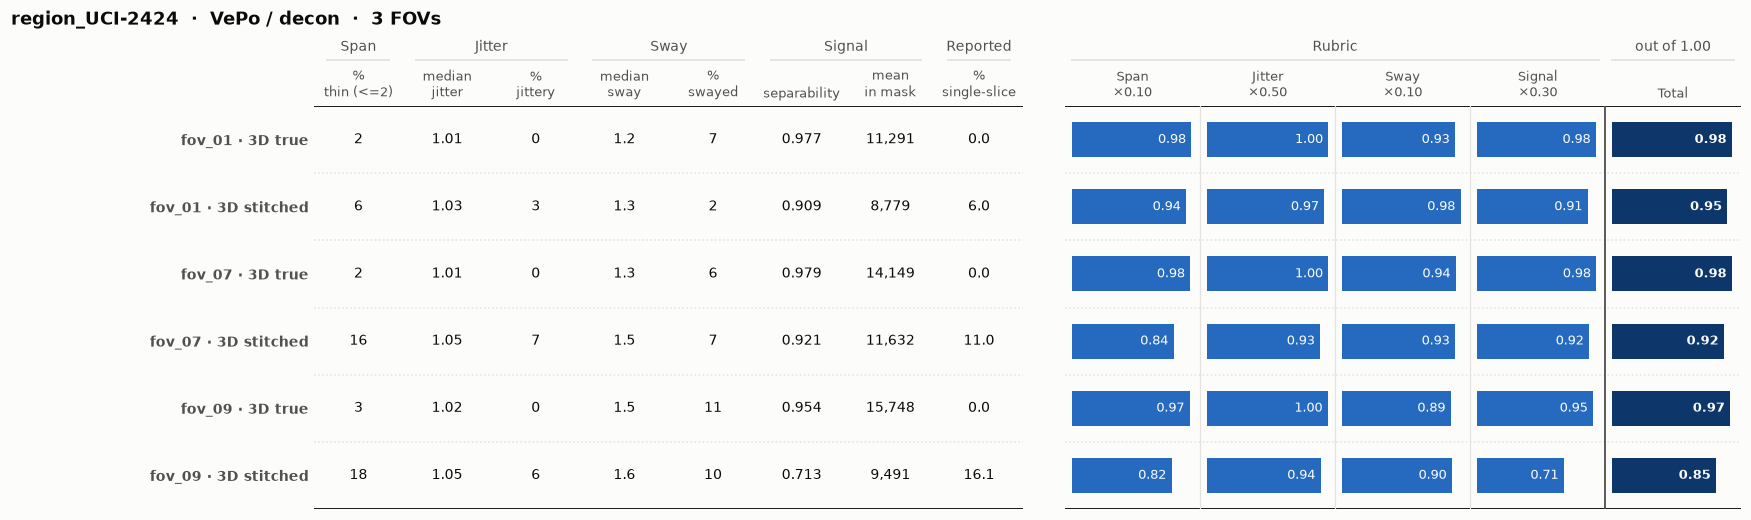

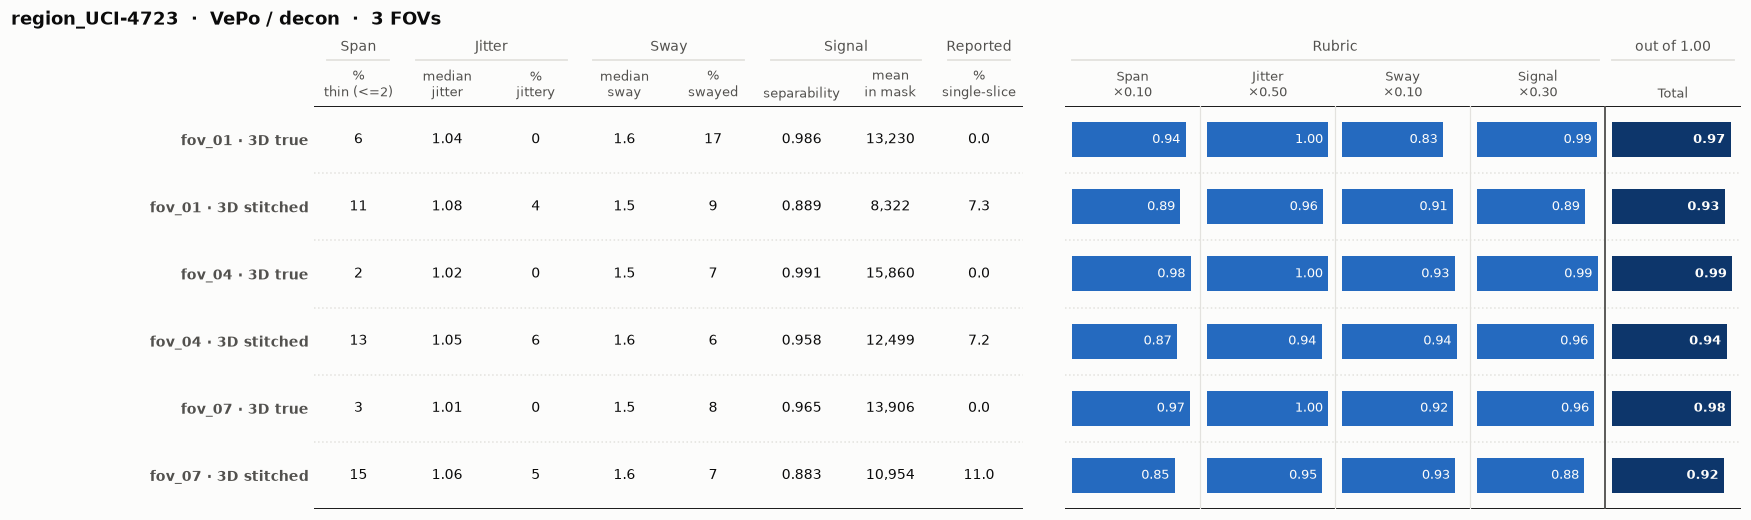

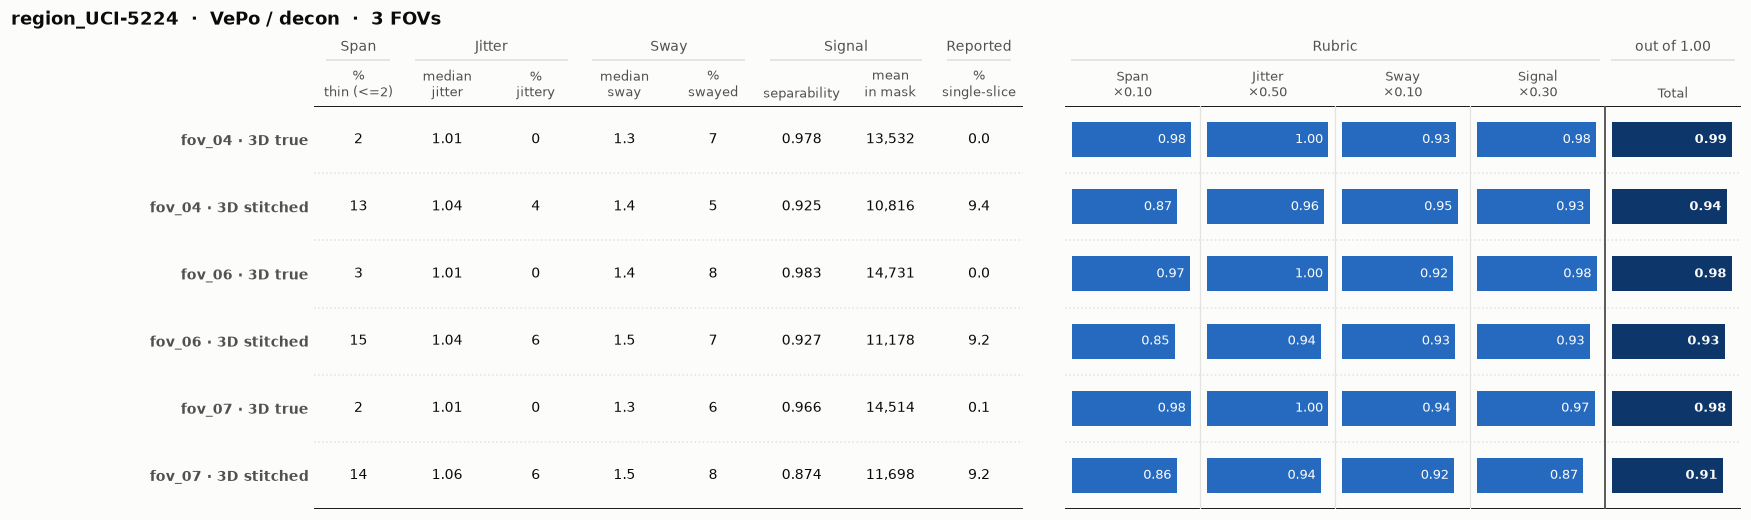

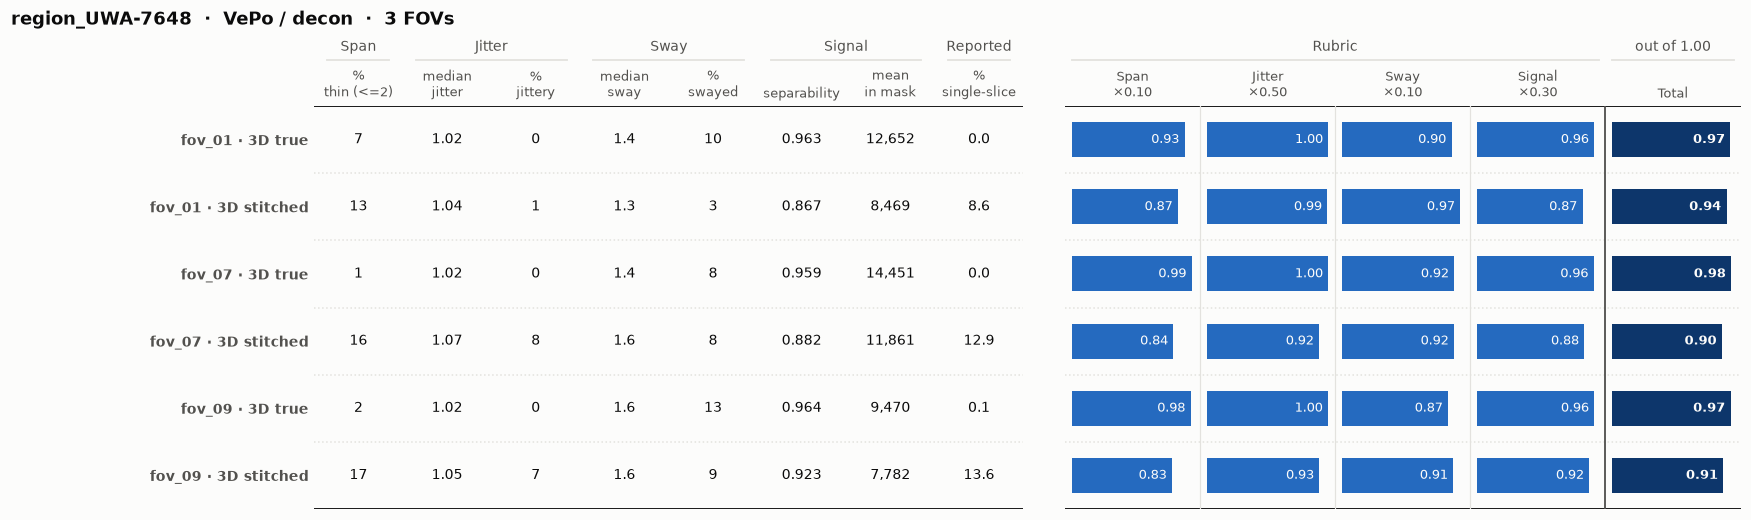

In [16]:
scores = v2.score_fovs(metrics)   # the numbers behind the bars, as a table

for region, block in metrics.groupby(level="region", sort=True, observed=True):
    # recomputed per block, and identical to the rows in `scores` above: the
    # subscores are absolute, so a row never depends on what shares its table
    fig = v2.plot_scorecard(
        block.droplevel("region"),
        title=f"{region}  ·  {MODEL} / {PREPROCESSING}  ·  "
              f"{block.index.get_level_values('fov').nunique()} FOVs")
    display(fig)
    plt.close(fig)      # displayed above; without this the inline backend repeats it

## 7. Looking at the flagged masks

Every defect measured above, as a label layer over the DAPI: each is a copy of
the mask volume with everything but the selected labels zeroed, so napari toggles
them without recomputing anything. The single-slice masks that were filtered out
come back as their own layer — worth a look at least once, to confirm they really
are artifacts in your data and not something the filter should be sparing.

The two brightness layers are boolean volumes rather than labels: "outside every
mask yet brighter than the median masked voxel" is not a label. Thresholds are
per technique, since each one's own distribution is what defines bright and dim
for it.

Building the layers is headless-safe; only the cell after it needs Qt, and it
blocks the kernel until both windows close, which is why `LAUNCH_NAPARI` is off
by default.

In [ ]:
viewer_layers = {}
for method, run in runs.items():
    viewer_layers[method] = v2.build_flag_layers(
        run["masks"], run["labels"], run["dropped"],
        dapi=dapi, counts=run["counts"], edges=run["edges"],
        thin_max=THIN_MAX, deep_min=DEEP_MIN)

    print(f"\n{method}")
    for name, volume in viewer_layers[method].items():
        n = int((np.unique(volume) > 0).sum())
        print(f"  {name:<44} {n:>5} label(s)" if volume.dtype != np.uint8
              else f"  {name:<44} {int(volume.sum()):>7,} voxel(s)")

In [ ]:
# One viewer per technique over the same DAPI, so the same nucleus can be found
# under each.  Blocks the kernel until every window is closed.
if LAUNCH_NAPARI:
    for method, run in runs.items():
        v2.launch_viewer(dapi, run["masks"], viewer_layers[method],
                         title=f"{REGION} {FOV} — {method}")

In [ ]:
# Planes are far enough apart that the 3D view is unusable unstretched.  Pass the
# z step divided by the pixel size; 15 is the default the scripts used.
if LAUNCH_NAPARI:
    v2.make_3d(z_scale=15)


### region_UCI-2424
skipping 2 FOV(s) missing from a technique: fov_01, fov_09
  fov_07     3D true       2551 masks   2293 measurable  (   1 single-slice dropped of  2552)
  fov_07     3D stitched   1957 masks   1640 measurable  ( 242 single-slice dropped of  2199)

4,508 masks kept (3,933 long enough to measure) across 1 FOV(s)


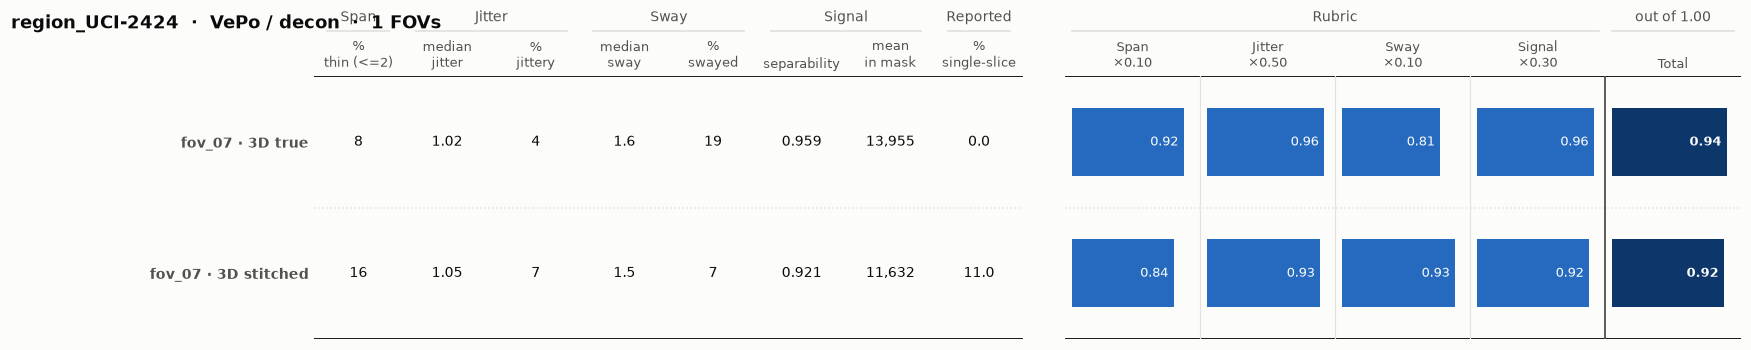

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import segmentation_helpers_v2 as v2

# --- what to score -----------------------------------------------------------
DATA_ROOT     = Path("../data")
FAMILY        = "cpdino"
PREPROCESSING = "decon"
MODEL         = "VePo"

REGION = "region_UCI-2424"

TECHNIQUE_ROOTS = {
    "3D true":     DATA_ROOT / "cpsam_v2_2/decon_decon_kde-median" / MODEL,
    "3D stitched": DATA_ROOT / "segmentations_3d_stitched" / FAMILY / PREPROCESSING / MODEL,
}
DAPI_PATCHES = DATA_ROOT / "patches" / MODEL

WITH_BRIGHTNESS = True    # False -> skip DAPI; Signal leaves the card and Total
                          # renormalises over the 0.70 that remains
# --- the single-slice filter -------------------------------------------------
DROP_SINGLE_SLICE    = True
DROP_SINGLE_SLICE_IN = None

# --- z-span ------------------------------------------------------------------
THIN_MAX = 2
DEEP_MIN = 6

JITTER_CUTOFF = 1.75
SWAY_CUTOFF   = 3.0
AREA_FLOOR    = 20
SLIVER_FRAC   = 0.05

# --- the rubric --------------------------------------------------------------
WEIGHTS = {"Span": 0.10, "Jitter": 0.50, "Sway": 0.10, "Signal": 0.30}
# =============================================================================

v2.apply_theme()
v2.SCORE_WEIGHTS = WEIGHTS

ANALYSIS = dict(jitter_cutoff=JITTER_CUTOFF, sway_cutoff=SWAY_CUTOFF,
                area_floor=AREA_FLOOR, sliver_frac=SLIVER_FRAC,
                thin_max=THIN_MAX, deep_min=DEEP_MIN)
FILTER = dict(drop=DROP_SINGLE_SLICE, drop_in=DROP_SINGLE_SLICE_IN)

# fail with the list of regions rather than a bare FileNotFoundError from inside
missing = [f"{name:<12} {root / REGION}"
           for name, root in TECHNIQUE_ROOTS.items() if not (root / REGION).is_dir()]
if missing:
    raise FileNotFoundError(
        f"{REGION} is not under every technique root:\n  " + "\n  ".join(missing)
        + "\n\nregions under both: "
        + (", ".join(v2.available_regions(TECHNIQUE_ROOTS)) or "(none)"))

scan = v2.scan_regions(TECHNIQUE_ROOTS,
                       DAPI_PATCHES if WITH_BRIGHTNESS else None,
                       regions=[REGION], **ANALYSIS, **FILTER)

metrics = v2.fov_metrics(scan["labels"], scan["brightness"], scan["filters"]).droplevel("region")
scores = v2.score_fovs(metrics)

n_fovs = metrics.index.get_level_values("fov").nunique()
print(f"\n{len(scan['labels']):,} masks kept "
      f"({int(scan['labels']['jitter'].notna().sum()):,} long enough to measure) "
      f"across {n_fovs} FOV(s)")

fig = v2.plot_scorecard(
    metrics,
    title=f"{REGION}  ·  {MODEL} / {PREPROCESSING}  ·  {n_fovs} FOVs")
display(fig)
plt.close(fig)          # displayed above; without this the inline backend repeats it
